# PICpy — Usage Guide

PICpy implements the **PIC (Pivotal Information Criterion)** framework for sparse GLM regression.
Regularisation is selected automatically via the **PDB (Pivotal Detection Boundary)** method — no cross-validation required.

**Installation**
```bash
pip install numpy pandas scipy scikit-learn matplotlib scienceplots
```

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from picpy import LinearRegression, LogisticRegression, CoxRegression
from picpy.families import Poisson, Gumbel
from picpy.penalties import SCADPenalty, MCPPenalty
from picpy.utils import StabilitySelection
from picpy.utils.visuals import plot_cox_summary, plot_stability, plot_pdb_distribution

# ── Synthetic data (300 obs, 30 features, 5 truly active) ──────────────
rng = np.random.default_rng(42)
n, p = 300, 30
X = rng.standard_normal((n, p))
beta_true = np.zeros(p)
beta_true[:5] = [2.0, -1.5, 1.2, -0.8, 0.6]

---
## 1. Linear Regression

Default: Gaussian family, L1 penalty, automatic PDB λ via Monte Carlo (`mc_exact`).

In [2]:
y = X @ beta_true + rng.standard_normal(n)

model = LinearRegression(
    lambda_n_simu = 5000,   # MC draws for PDB (default)
    lambda_alpha  = 0.05,   # type-I error level (default)
    tol           = 1e-8,   # FISTA convergence tolerance (default)
)
model.fit(X, y)
model.summary()

+---------------------------------------------------+
|   Model           : LinearRegression              |
|   Family          :   Gaussian                    |
|   Penalty         :  L1Penalty                    |
|   n               :        300                    |
|   p               :         30                    |
|   fit_intercept   :       True                    |
+---------------------------------------------------+
|   lambda (PDB)    :     0.1811                    |
|   alpha           :     0.0500                    |
+---------------------------------------------------+
|   Selected variables (5 / 30)                     |
|   feature         :       coef                    |
|   0               :    +1.7019                    |
|   1               :    -1.4824                    |
|   2               :    +0.9041                    |
|   3               :    -0.6945                    |
|   4               :    +0.3522                    |
|   intercept       :    -0.

'+---------------------------------------------------+\n|   Model           : LinearRegression              |\n|   Family          :   Gaussian                    |\n|   Penalty         :  L1Penalty                    |\n|   n               :        300                    |\n|   p               :         30                    |\n|   fit_intercept   :       True                    |\n+---------------------------------------------------+\n|   lambda (PDB)    :     0.1811                    |\n|   alpha           :     0.0500                    |\n+---------------------------------------------------+\n|   Selected variables (5 / 30)                     |\n|   feature         :       coef                    |\n|   0               :    +1.7019                    |\n|   1               :    -1.4824                    |\n|   2               :    +0.9041                    |\n|   3               :    -0.6945                    |\n|   4               :    +0.3522                    |\n|   inter

In [3]:
# Coefficient table — sorted by |coef|, selected features first
print(model.coef_table.head(8))

print(f"\nTrue active : {list(range(5))}")
print(f"Selected    : {model.selected_features_.tolist()}")

             coef  abs_coef  selected
feature                              
0        1.701906  1.701906      True
1       -1.482352  1.482352      True
2        0.904061  0.904061      True
3       -0.694532  0.694532      True
4        0.352224  0.352224      True
5        0.000000  0.000000     False
6        0.000000  0.000000     False
7       -0.000000  0.000000     False

True active : [0, 1, 2, 3, 4]
Selected    : [0, 1, 2, 3, 4]


In [4]:
# Optional unpenalised refit on selected support (reduces shrinkage bias)
model_refit = LinearRegression()
model_refit.fit(X, y, refit=True)

print(f"Penalised coef[0] : {model.coef_[0]:.4f}")
print(f"Refitted  coef[0] : {model_refit.coef_[0]:.4f}")
print(f"True      coef[0] : {beta_true[0]:.4f}")

Penalised coef[0] : 1.7019
Refitted  coef[0] : 1.9209
True      coef[0] : 2.0000


---
## 2. Families and Penalties

Any `Family` and `Penalty` can be combined.  The warm-up path always uses L1; the specified penalty is applied at the final step.

In [5]:
# ── Poisson count data with SCAD penalty ───────────────────────────────
y_count = rng.poisson(np.exp(X[:, :5] @ beta_true[:5] * 0.5))

model_scad = LinearRegression(family=Poisson(), penalty=SCADPenalty(a=3.7))
model_scad.fit(X, y_count)
print(f"Poisson + SCAD  — λ={model_scad.lambda_:.4f}, selected={model_scad.selected_features_.tolist()}")

# ── Gaussian with MCP penalty ─────────────────────────────────────────
model_mcp = LinearRegression(penalty=MCPPenalty(gamma=3.0))
model_mcp.fit(X, y)
print(f"Gaussian + MCP  — λ={model_mcp.lambda_:.4f}, selected={model_mcp.selected_features_.tolist()}")

# ── Gumbel (extreme-value) family ─────────────────────────────────────
y_gumbel = rng.gumbel(loc=X @ beta_true, scale=1.0)

model_gumbel = LinearRegression(family=Gumbel())
model_gumbel.fit(X, y_gumbel)
print(f"Gumbel  + L1    — λ={model_gumbel.lambda_:.4f}, selected={model_gumbel.selected_features_.tolist()}")

Poisson + SCAD  — λ=0.1812, selected=[0, 1, 2, 3, 4]
Gaussian + MCP  — λ=0.1812, selected=[0, 1, 2, 3, 4]
Gumbel  + L1    — λ=0.8838, selected=[0, 1, 2, 3, 4]


---
## 3. Lambda Computation Methods

Three methods are available for computing λ, with different accuracy/speed trade-offs.
The approximations are valid when *n* is large relative to *p*.

| Method | Description | Requires simulation |
|---|---|---|
| `mc_exact` | Exact MC from family null (default) | Yes |
| `mc_gaussian` | Gaussian CLT approx — draws $W\sim N(0,I_n)$, avoids null MLE fitting | Yes |
| `analytical` | Bonferroni bound $\lambda = \Phi^{-1}(1-\alpha/2p)/\sqrt{n}$ | No |

---
## 4. Logistic Regression

Binary classification with Binomial loss and logistic link. `score` returns classification accuracy.

In [25]:
proba = 1.0 / (1.0 + np.exp(-X @ beta_true))
y_bin = rng.binomial(1, proba)

model = LogisticRegression(penalty=SCADPenalty())
model.fit(X, y_bin)
model.summary()

print(f"\nAccuracy : {model.score(X, y_bin):.3f}")
print(f"Proba of first 5 : {model.predict_proba(X[:5])}")

+---------------------------------------------------+
|   Model           : LogisticRegression            |
|   Family          :   Binomial                    |
|   Penalty         : SCADPenalty                   |
|   n               :        300                    |
|   p               :         30                    |
|   fit_intercept   :       True                    |
+---------------------------------------------------+
|   lambda (PDB)    :     0.1804                    |
|   alpha           :     0.0500                    |
+---------------------------------------------------+
|   Selected variables (5 / 30)                     |
|   feature         :       coef                    |
|   0               :    +1.9219                    |
|   1               :    -0.9844                    |
|   2               :    +0.8438                    |
|   3               :    -0.0863                    |
|   29              :    +0.0772                    |
|   intercept       :    +0.

---
## 5. Cox Regression

Sparse proportional hazards model via Breslow partial likelihood.  
Response `y` must be a 2-column array `[time, event]`. `score` returns Harrell's C-index.

In [26]:
lp = X[:, :3] @ beta_true[:3]
T  = -np.log(rng.uniform(size=n)) / np.exp(lp)   # exponential survival times
C  = np.quantile(T, 0.8)                           # administrative censoring
y_surv = np.column_stack([np.minimum(T, C), (T <= C).astype(int)])

cox = CoxRegression()
cox.fit(X, y_surv)
cox.summary()

print(f"\nC-index : {cox.score(X, y_surv):.3f}")

+---------------------------------------------------+
|   Model           : CoxRegression                 |
|   Family          :        Cox                    |
|   Penalty         :  L1Penalty                    |
|   n               :        300                    |
|   p               :         30                    |
|   fit_intercept   :      False                    |
+---------------------------------------------------+
|   lambda (PDB)    :     0.0410                    |
|   alpha           :     0.0500                    |
+---------------------------------------------------+
|   Selected variables (3 / 30)                     |
|   feature         :       coef                    |
|   0               :    +1.1646                    |
|   1               :    -0.7988                    |
|   2               :    +0.4849                    |
+---------------------------------------------------+

C-index : 0.879


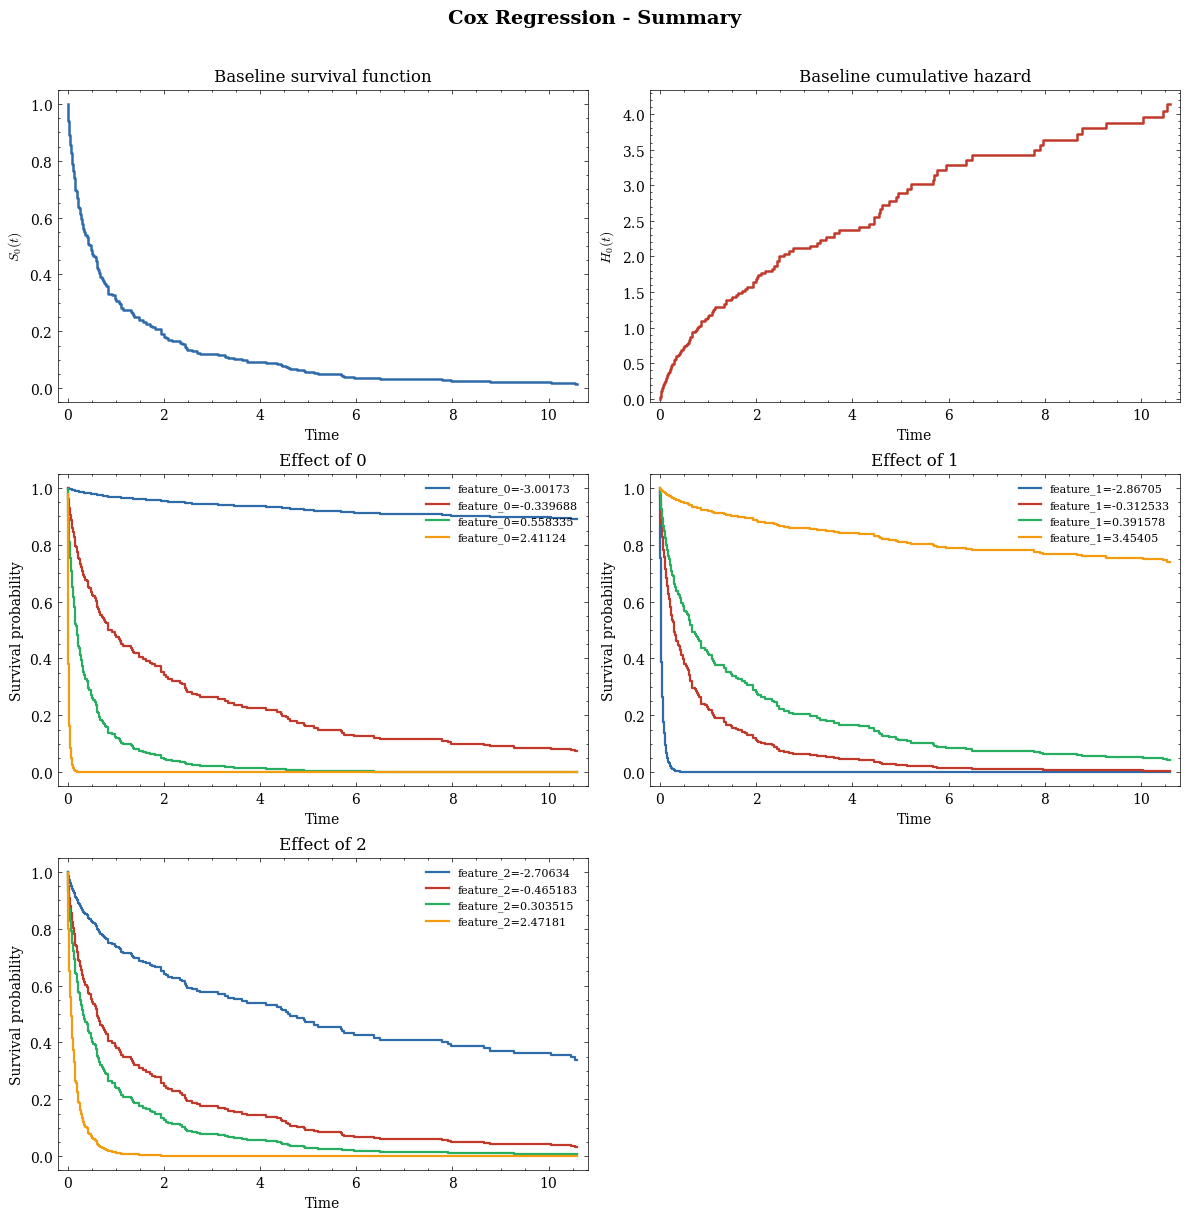

In [27]:
# Big-picture summary: baseline curves + per-feature survival effects
fig = plot_cox_summary(cox, X)
plt.show()

---
## 6. Stability Selection

`StabilitySelection` refits the model on `m` random half-subsamples and reports  
how often each feature is selected. High frequency → stably selected.

In [ ]:
ss = StabilitySelection(
    model             = LinearRegression(lambda_method="analytical"),
    m                 = 100,    # number of subsamples
    subsample_fraction= 0.5,
    random_state      = 42,
)
ss.fit(X, y)

print(ss.selection_table_.head(8))
print(f"\nSubsamples failed : {ss.n_failed_}")

         selection_frequency  n_selected
feature                                 
0                       1.00         100
2                       1.00         100
3                       1.00         100
1                       1.00         100
4                       0.96          96
27                      0.01           1
13                      0.01           1
22                      0.00           0

Subsamples failed : 0


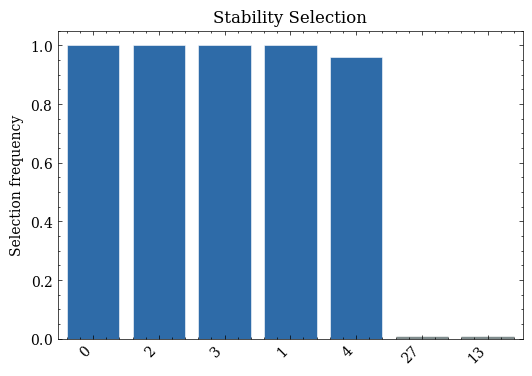

In [29]:
# Bar chart — features above threshold (dashed line) are stably selected
ss.plot(threshold=0.6)
plt.show()

---
## 7. PDB Null Distribution

After fitting, the PDB selector exposes the full simulated null distribution.  
`pdb_selector.summary()` prints key quantiles; `plot_pdb_distribution` visualises it.

In [34]:
model_pdb = LinearRegression(lambda_n_simu=5000)
model_pdb.fit(X, y)
pdb_sel = model_pdb.pdb_selector
pdb_sel.summary()

+---PDB Selector-----------------+
|  method          :   mc_exact  |
|  n_simu          :      5,000  |
|  alpha           :      0.050  |
|  lambda (PDB)    :      0.181  |
+---Null distribution------------+
|  mean            :     0.1340  |
|  std             :     0.0261  |
|  25th pct        :     0.1153  |
|  median          :     0.1312  |
|  75th pct        :     0.1507  |
+--------------------------------+


'+---PDB Selector-----------------+\n|  method          :   mc_exact  |\n|  n_simu          :      5,000  |\n|  alpha           :      0.050  |\n|  lambda (PDB)    :      0.181  |\n+---Null distribution------------+\n|  mean            :     0.1340  |\n|  std             :     0.0261  |\n|  25th pct        :     0.1153  |\n|  median          :     0.1312  |\n|  75th pct        :     0.1507  |\n+--------------------------------+'

<Axes: title={'center': 'PDB null distribution'}, xlabel='Null statistic', ylabel='Density'>

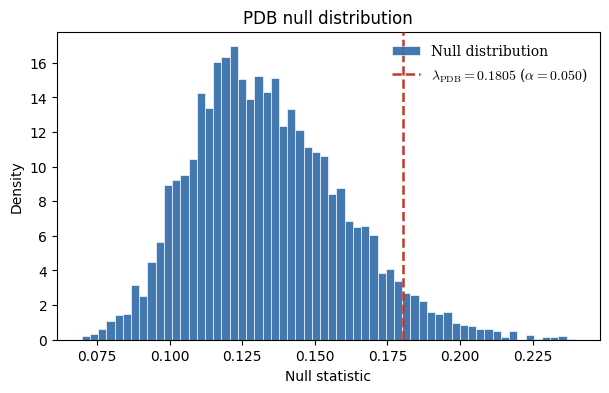

In [35]:
pdb_sel.plot_pdb_distribution()